Importing libraries

In [2]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

Creating dataset

In [3]:


data = {
    "label": [
        "ham","spam","ham","spam","ham","spam","ham","spam","ham","spam",
        "ham","spam","ham","spam","ham","spam","ham","spam","ham","spam"
    ],
    "text": [
        "Hi we will meet tomorrow at the office",
        "Congratulations you have won a free iPhone click now",
        "Please find the attached assignment for today",
        "Limited time offer buy one get one free",
        "Can we reschedule the meeting to Monday",
        "You have been selected for a cash prize claim now",
        "Let us discuss the project after lunch",
        "Win money instantly by clicking this link",
        "Your appointment with the doctor is confirmed",
        "Exclusive deal just for you buy now",
        "Please call me when you are free",
        "Get cheap loans approved instantly",
        "The class has been postponed to next week",
        "Congrats you are the lucky winner of lottery",
        "Meeting minutes are shared in the email",
        "Free coupons available hurry up",
        "Happy birthday wish you a great year ahead",
        "Act now your account will be suspended",
        "The exam schedule has been uploaded",
        "Claim your reward by verifying your details"
    ]
}

df = pd.DataFrame(data)
df.head()

,label,text
0,ham,Hi we will meet tomorrow at the office
1,spam,Congratulations you have won a free iPhone cli...
2,ham,Please find the attached assignment for today
3,spam,Limited time offer buy one get one free
4,ham,Can we reschedule the meeting to Monday


Encode Labels

In [4]:
df["label"] = df["label"].map({"ham": 0, "spam": 1})

In [5]:
print(df.head())

   label                                               text
0      0             Hi we will meet tomorrow at the office
1      1  Congratulations you have won a free iPhone cli...
2      0      Please find the attached assignment for today
3      1            Limited time offer buy one get one free
4      0            Can we reschedule the meeting to Monday


Convert Text → Numerical Features

In [6]:
vectorizer = CountVectorizer(stop_words="english")
X = vectorizer.fit_transform(df["text"])
y = df["label"]

In [7]:
print(X)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 76 stored elements and shape (20, 69)>
  Coords	Values
  (0, 30)	1
  (0, 42)	1
  (0, 60)	1
  (0, 48)	1
  (1, 18)	1
  (1, 67)	1
  (1, 27)	1
  (1, 33)	1
  (1, 14)	1
  (2, 6)	1
  (2, 5)	1
  (2, 59)	1
  (3, 27)	1
  (3, 36)	1
  (3, 58)	1
  (3, 47)	1
  (3, 9)	1
  (4, 52)	1
  (4, 43)	1
  (4, 45)	1
  (5, 55)	1
  (5, 10)	1
  (5, 50)	1
  (5, 12)	1
  (6, 35)	1
  :	:
  (13, 39)	1
  (14, 43)	1
  (14, 44)	1
  (14, 56)	1
  (14, 24)	1
  (15, 27)	1
  (15, 19)	1
  (15, 7)	1
  (15, 31)	1
  (16, 29)	1
  (16, 8)	1
  (16, 66)	1
  (16, 28)	1
  (16, 68)	1
  (16, 2)	1
  (17, 1)	1
  (17, 0)	1
  (17, 57)	1
  (18, 25)	1
  (18, 54)	1
  (18, 61)	1
  (19, 12)	1
  (19, 53)	1
  (19, 62)	1
  (19, 21)	1


Train–Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

Train the Decision Tree

In [9]:
dt = DecisionTreeClassifier(
    criterion="entropy",   # uses Information Gain
    max_depth=5,           # prevents overfitting
    random_state=42
)

dt.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)

Evaluate the Model

In [10]:
y_pred = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.4

Confusion Matrix:
 [[2 0]
 [3 0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.40      1.00      0.57         2
           1       0.00      0.00      0.00         3

    accuracy                           0.40         5
   macro avg       0.20      0.50      0.29         5
weighted avg       0.16      0.40      0.23         5



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Test with a New Email

In [11]:
sample = ["You have won a free cash prize"]
sample_vec = vectorizer.transform(sample)

prediction = dt.predict(sample_vec)

print("Spam" if prediction[0] == 1 else "Not Spam")

Not Spam


Visualize the Decision Tree

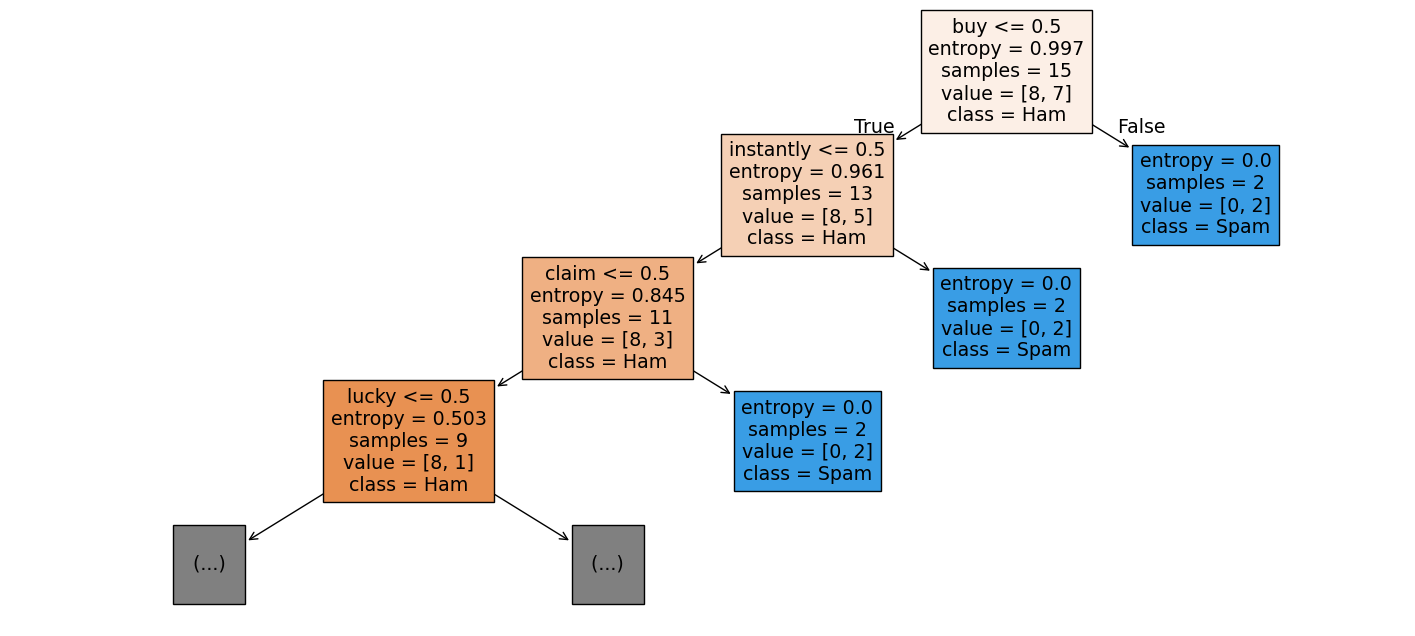

In [12]:
plt.figure(figsize=(18,8))
plot_tree(
    dt,
    feature_names=vectorizer.get_feature_names_out(),
    class_names=["Ham", "Spam"],
    filled=True,
    max_depth=3
)
plt.show()